In [4]:
!pip install transformers torchvision pillow scikit-learn -q


In [8]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

Using: cpu


In [9]:
ads = pd.read_csv('ads_enriched.csv')
events = pd.read_csv('ad_events.csv')
campaigns = pd.read_csv('campaigns.csv')
users = pd.read_csv('users.csv')

In [12]:
#building engagement score again
weights = {'Impression ': 0, 'Click': 1,'Like': 2,'Comment': 3,'Share': 4,'Purchase': 5}
events['engagement_weight'] = events['event_type'].map(weights)

engagement = (
    events.groupby(['ad_id','user_id'])['engagement_weight'].sum()
    .reset_index().rename(columns = { 'engagement_weight': 'engagement_score' })
)

print(f"Total pairs: {len(engagement):,}")
print(engagement['engagement_score'].value_counts().head())

Total pairs: 206,789
engagement_score
0.0    174082
1.0     21549
2.0      6624
3.0      2316
5.0      1108
Name: count, dtype: int64


In [18]:
#merging and filtering

df = engagement.merge(ads, on='ad_id')
df = df.merge(campaigns[['campaign_id', 'total_budget', 'duration_days']], on='campaign_id')
df = df.merge(users[['user_id', 'user_age', 'user_gender']], on = 'user_id')
df = df[df['engagement_score']>0].copy().reset_index(drop=True)

print(f"Engaged rows: {len(df):,}")
print(f"Score range: {df['engagement_score'].min()} - {df['engagement_score'].max()}")

Engaged rows: 33,033
Score range: 1.0 - 8.0


Sample shape: (2000, 17)
Y range: 0.693 to 2.079


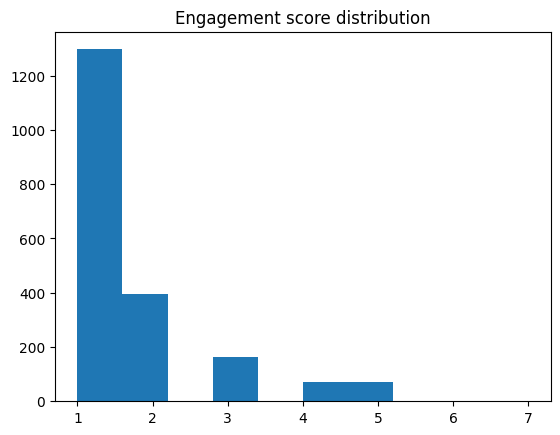

In [20]:
df_sample = df.sample(n=2000, random_state = 42).reset_index(drop=True)

y_tensor = torch.FloatTensor(
    np.log1p(df_sample['engagement_score'].values).reshape(-1,1)
)

print(f"Sample shape: {df_sample.shape}")
print(f"Y range: {y_tensor.min():.3f} to {y_tensor.max():.3f}")

plt.hist(df_sample['engagement_score'], bins = 10)
plt.title("Engagement score distribution")
plt.show()

In [27]:
#image embedder

class ImageEmbedder(nn.Module):
  def __init__(self):
    super().__init__()

    resnet = models.resnet50(pretrained = True)
    for param in resnet.parameters():
      param.requires_grad = False

    self.backbone = nn.Sequential(*list(resnet.children())[:-1])
    self.embedding_head = nn.Sequential(
        nn.Flatten(),
        nn.Linear(2048, 512),
        nn.ReLU()
    )

    def forward(self, x):
      return self.embedding_head(self.backbone(x))

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

image_embedder = ImageEmbedder().to(device)
image_embedder.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ImageEmbedder(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv